In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import collections, re
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection

In [126]:
data = pd.read_csv("final_defesas_2006a2024.csv")
data_filiacao = pd.read_csv("csvs/filiacao.csv")
data_genero = pd.read_csv("csvs/genero2.csv")

In [127]:
padrao_avaliadores = 'avaliador\d$'
avaliadores = [col for col in data.columns if re.search(padrao_avaliadores, col)]
avaliadores.append("orientador")

In [128]:
uni_key = {uni:key for key, uni in enumerate(data_filiacao["filiacao padronizada"].unique())}

In [129]:
css4_colors = list(mcolors.CSS4_COLORS.keys())

# You can use the first 130 of these colors
palette_130 = css4_colors[:data_filiacao["filiacao padronizada"].unique().shape[0]]

## Triângulos

In [130]:
# grafo_defesas = nx.MultiDiGraph()
grafo_defesas_single_undirected = nx.Graph()
n_banca = 0
filiacao_alvo = "Universidade Estadual de Campinas"
cor_nodes = []
cor_nodes_bin = []
marker_node = []
for col in avaliadores:
    if "_" in col: continue
    if col == "ano": continue
    # if "orientador" not in "col"
    for index, url in zip(data[col].index, data[col]):
        if url != url: continue
        elif url == "sem orcid": continue
        filiacao = data_filiacao[data_filiacao["orcid"] == url]["filiacao padronizada"].values[0]\
                                                            if data_filiacao[data_filiacao["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        genero = data_genero[data_genero["orcid"] == url]["genero"].values[0]\
                                                            if data_genero[data_genero["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        filiacao_genero=f'{genero}_{"interno" if filiacao==filiacao_alvo else "externo"}'
        grafo_defesas_single_undirected.add_node(
                            node_for_adding=url.split("/")[-1],
                            nome=data.at[index, f"{col}_nome"],
                            filiacao=filiacao,
                            genero=genero,
                            filiacao_genero=filiacao_genero,
                            bipartite=1 if genero == "Feminino" else 0,
                            marker="F" if genero == "Feminino" else "M",
                            cor_bin="red" if filiacao == filiacao_alvo else "blue",
                            cor=palette_130[uni_key[filiacao]]
                            )
    n_banca -=- 1

In [131]:
size_nodes = []

for row in data.iterrows():
    # print(row[0], row[1]["orientador"])
    # break
    # a.add_edge(row[1]["orientador"], row[1]["avaliador1"])
    if row[1]["orientador"] != row[1]["orientador"]: continue
    if row[1]["orientador"] == "sem orcid": continue
    orcid_orient = row[1]["orientador"].split("/")[-1]
    for i in range(1, n_banca):
        if row[1][f"avaliador{i}"] != row[1][f"avaliador{i}"]: continue
        if row[1][f"avaliador{i}"] == "sem orcid": continue
        # if "Eliane Martins" == row[1][f"avaliador{i}_nome"].split("/")[-1]: print("ola_aval")
        # if "Eliane Martins" == row[1][f"orientador_nome"].split("/")[-1]: print("ola_orient")
        orcid_aval = row[1][f"avaliador{i}"].split("/")[-1]
        if grafo_defesas_single_undirected.has_edge(orcid_orient, orcid_aval):
            grafo_defesas_single_undirected[orcid_orient][orcid_aval]["weight"] -=- 1
            continue
        grafo_defesas_single_undirected.add_edge(orcid_orient, orcid_aval, ano=row[1]["ano"], tipo=row[1]["tipo"], weight=1)
        ## aresta direcionada: orientadora/orientador -> avaliador/avaliadora
        # grafo_defesas.add_(orcid_orient, orcid_aval, qtd=1)
edge_widths = []
# for p1, p2 in grafo_defesas.edges:
#     edge_widths.append(1 * grafo_defesas[p1][p2]["qtd"])

In [132]:
triangles = nx.triangles(grafo_defesas_single_undirected)

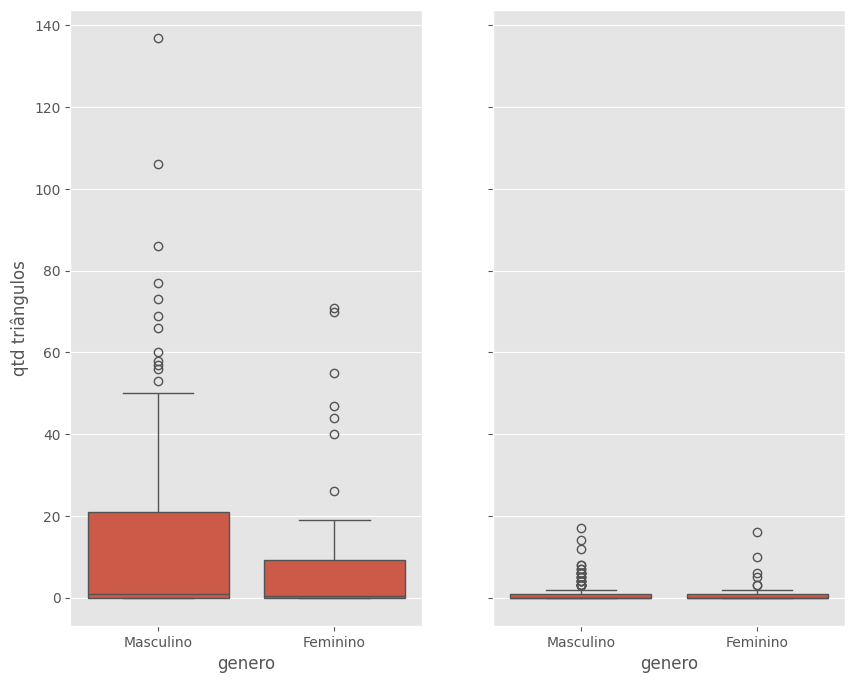

In [134]:
df_tri = collections.defaultdict(list)
for person, qtd in triangles.items():
    info = grafo_defesas_single_undirected.nodes[person]
    df_tri["genero"].append(info["genero"])
    df_tri["qtd triângulos"].append(qtd)
    df_tri["filiacao_genero"].append(info["filiacao_genero"])
df_tri = pd.DataFrame(df_tri)
fig, ax = plt.subplots(ncols=2, figsize=(10,8), sharey=True)
sns.boxplot(data=df_tri[df_tri["filiacao_genero"].str.endswith("interno")], x="genero", y="qtd triângulos",
            ax=ax[0])
sns.boxplot(data=df_tri[df_tri["filiacao_genero"].str.endswith("externo")], x="genero", y="qtd triângulos",
            ax=ax[1])
plt.show()

## Clusterização

In [135]:
# grafo_defesas = nx.MultiDiGraph()
grafo_defesas_single_directed = nx.DiGraph()
n_banca = 0
filiacao_alvo = "Universidade Estadual de Campinas"
cor_nodes = []
cor_nodes_bin = []
marker_node = []
for col in avaliadores:
    if "_" in col: continue
    if col == "ano": continue
    # if "orientador" not in "col"
    for index, url in zip(data[col].index, data[col]):
        if url != url: continue
        elif url == "sem orcid": continue
        filiacao = data_filiacao[data_filiacao["orcid"] == url]["filiacao padronizada"].values[0]\
                                                            if data_filiacao[data_filiacao["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        genero = data_genero[data_genero["orcid"] == url]["genero"].values[0]\
                                                            if data_genero[data_genero["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        filiacao_genero=f'{genero}_{"interno" if filiacao==filiacao_alvo else "externo"}'
        grafo_defesas_single_directed.add_node(
                            node_for_adding=url.split("/")[-1],
                            nome=data.at[index, f"{col}_nome"],
                            filiacao=filiacao,
                            genero=genero,
                            filiacao_genero=filiacao_genero,
                            bipartite=1 if genero == "Feminino" else 0,
                            marker="F" if genero == "Feminino" else "M",
                            cor_bin="red" if filiacao == filiacao_alvo else "blue",
                            cor=palette_130[uni_key[filiacao]]
                            )
    n_banca -=- 1

In [136]:
size_nodes = []

for row in data.iterrows():
    # print(row[0], row[1]["orientador"])
    # break
    # a.add_edge(row[1]["orientador"], row[1]["avaliador1"])
    if row[1]["orientador"] != row[1]["orientador"]: continue
    if row[1]["orientador"] == "sem orcid": continue
    orcid_orient = row[1]["orientador"].split("/")[-1]
    for i in range(1, n_banca):
        if row[1][f"avaliador{i}"] != row[1][f"avaliador{i}"]: continue
        if row[1][f"avaliador{i}"] == "sem orcid": continue
        # if "Eliane Martins" == row[1][f"avaliador{i}_nome"].split("/")[-1]: print("ola_aval")
        # if "Eliane Martins" == row[1][f"orientador_nome"].split("/")[-1]: print("ola_orient")
        orcid_aval = row[1][f"avaliador{i}"].split("/")[-1]
        if grafo_defesas_single_directed.has_edge(orcid_orient, orcid_aval):
            grafo_defesas_single_directed[orcid_orient][orcid_aval]["weight"] -=- 1
            continue
        grafo_defesas_single_directed.add_edge(orcid_orient, orcid_aval, ano=row[1]["ano"], tipo=row[1]["tipo"], weight=1)
        ## aresta direcionada: orientadora/orientador -> avaliador/avaliadora
        # grafo_defesas.add_(orcid_orient, orcid_aval, qtd=1)
edge_widths = []
# for p1, p2 in grafo_defesas.edges:
#     edge_widths.append(1 * grafo_defesas[p1][p2]["qtd"])

In [137]:
clustering = nx.clustering(grafo_defesas_single_directed, weight="weight")
np.mean([v for v in clustering.values()])

np.float64(0.013196559310536602)

In [138]:
clustering = nx.clustering(grafo_defesas_single_directed, weight="weight",
                          nodes=[node for node in grafo_defesas_single_directed.nodes() if grafo_defesas_single_directed.nodes[node]["genero"]=="Feminino"])
np.mean([v for v in clustering.values()])

np.float64(0.014072020018893053)

In [139]:
clustering = nx.clustering(grafo_defesas_single_directed, weight="weight",
                          nodes=[node for node in grafo_defesas_single_directed.nodes() if grafo_defesas_single_directed.nodes[node]["genero"]=="Masculino"])
np.mean([v for v in clustering.values()])

np.float64(0.012979501763062671)

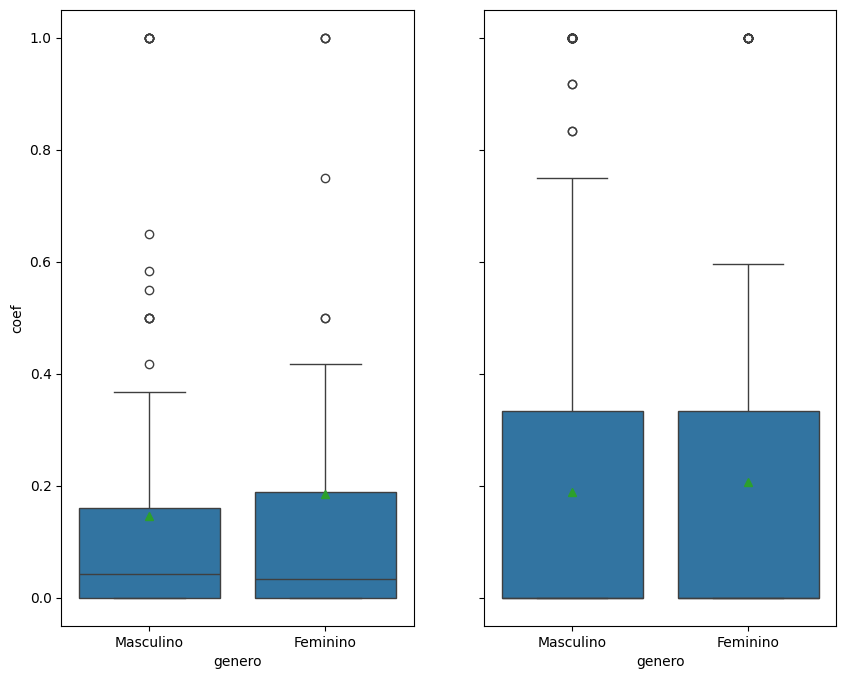

In [33]:
df_clustering = collections.defaultdict(list)
for person, coef in clustering.items():
    info = grafo_defesas_single_directed.nodes[person]
    df_clustering["genero"].append(info["genero"])
    df_clustering["coef"].append(coef)
    df_clustering["filiacao_genero"].append(info["filiacao_genero"])
df_clustering = pd.DataFrame(df_clustering)
fig, ax = plt.subplots(ncols=2, figsize=(10,8), sharey=True)
sns.boxplot(data=df_clustering[df_clustering["filiacao_genero"].str.endswith("interno")],
            x="genero", y="coef", showmeans=True,
            ax=ax[0])
sns.boxplot(data=df_clustering[df_clustering["filiacao_genero"].str.endswith("externo")],
            x="genero", y="coef", showmeans=True,
            ax=ax[1])
plt.show()

## Comunidade

In [22]:
G = nx.barbell_graph(5, 1)
communities_generator = nx.community.girvan_newman(G)
top_level_communities = next(communities_generator)
next_level_communities = next(communities_generator)
sorted(map(sorted, next_level_communities))

[[0, 1, 2, 3, 4], [5], [6, 7, 8, 9, 10]]

In [23]:
sorted(map(sorted, top_level_communities))

[[0, 1, 2, 3, 4], [5, 6, 7, 8, 9, 10]]

In [35]:
coms = nx.community.girvan_newman(grafo_defesas_single_directed)

In [36]:
for c in coms:
    break

In [45]:
for c_ in c:
    print(len(c_))

479
1
1
1
1
1
1
15
3
1
1
1
4
3
1


## Componente fortemente conectada

In [147]:
grafo_defesas = nx.MultiDiGraph()
# grafo_defesas = nx.DiGraph()
n_banca = 0
filiacao_alvo = "Universidade Estadual de Campinas"
cor_nodes = []
cor_nodes_bin = []
marker_node = []
for col in avaliadores:
    if "_" in col: continue
    if col == "ano": continue
    # if "orientador" not in "col"
    for index, url in zip(data[col].index, data[col]):
        if url != url: continue
        elif url == "sem orcid": continue
        filiacao = data_filiacao[data_filiacao["orcid"] == url]["filiacao padronizada"].values[0]\
                                                            if data_filiacao[data_filiacao["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        genero = data_genero[data_genero["orcid"] == url]["genero"].values[0]\
                                                            if data_genero[data_genero["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        filiacao_genero=f'{genero}_{"interno" if filiacao==filiacao_alvo else "externo"}'
        grafo_defesas.add_node(
                            node_for_adding=url.split("/")[-1],
                            nome=data.at[index, f"{col}_nome"],
                            filiacao=filiacao,
                            genero=genero,
                            filiacao_genero=filiacao_genero,
                            bipartite=1 if genero == "Feminino" else 0,
                            marker="F" if genero == "Feminino" else "M",
                            cor_bin="red" if filiacao == filiacao_alvo else "blue",
                            cor=palette_130[uni_key[filiacao]]
                            )
    n_banca -=- 1

In [148]:
size_nodes = []

for row in data.iterrows():
    # print(row[0], row[1]["orientador"])
    # break
    # a.add_edge(row[1]["orientador"], row[1]["avaliador1"])
    if row[1]["orientador"] != row[1]["orientador"]: continue
    if row[1]["orientador"] == "sem orcid": continue
    orcid_orient = row[1]["orientador"].split("/")[-1]
    for i in range(1, n_banca):
        if row[1][f"avaliador{i}"] != row[1][f"avaliador{i}"]: continue
        if row[1][f"avaliador{i}"] == "sem orcid": continue
        # if "Eliane Martins" == row[1][f"avaliador{i}_nome"].split("/")[-1]: print("ola_aval")
        # if "Eliane Martins" == row[1][f"orientador_nome"].split("/")[-1]: print("ola_orient")
        orcid_aval = row[1][f"avaliador{i}"].split("/")[-1]
        # if grafo_defesas.has_edge(orcid_orient, orcid_aval):
        #     grafo_defesas[orcid_orient][orcid_aval][0]["weight"] -=- 1
        #     continue
        grafo_defesas.add_edge(orcid_orient, orcid_aval, ano=row[1]["ano"], tipo=row[1]["tipo"])
        ## aresta direcionada: orientadora/orientador -> avaliador/avaliadora
        # grafo_defesas.add_(orcid_orient, orcid_aval, qtd=1)
edge_widths = []
# for p1, p2 in grafo_defesas.edges:
#     edge_widths.append(1 * grafo_defesas[p1][p2]["qtd"])

In [57]:
sccs = nx.strongly_connected_components(grafo_defesas)
largest = max(sccs, key=len)

In [58]:
pos = nx.drawing.nx_pydot.graphviz_layout(grafo_defesas, prog="twopi")

In [67]:
ano = 2006
edge_ano = []
nos_w_edge_ano = []
k_ano = []
pesos_arestas = collections.defaultdict(lambda:1.)
cores=collections.defaultdict(int)
marcadores=collections.defaultdict(str)
cores_bin=collections.defaultdict(int)
pesos = collections.defaultdict(lambda: 150)
cores_arestas = collections.defaultdict(lambda:"black")
scale=1
for ano in range(2006, 2025):
    for person1, person2, infos in grafo_defesas.edges(data=True):
        node1 = grafo_defesas.nodes[person1]
        node2 = grafo_defesas.nodes[person2]
        if infos["ano"] != ano: continue
        if node1["genero"] == node2["genero"]:
            if node1["genero"] == "Feminino":
                cores_arestas[(person1, person2)] = "green"
            else:
                cores_arestas[(person1, person2)] = "crimson"
        # else:
        #     cores_arestas.append("black")
        
        nos_w_edge_ano.append((person1, node1["genero"]))
        nos_w_edge_ano.append((person2, node2["genero"]))
        pesos_arestas[(person1, person2)]-=-.1
        edge_ano.append((person1, person2))
        pesos[person1]-=-10
        # pesos[person2]=150
        cores[person1]=node1["cor"]
        cores[person2]=node2["cor"]
        cores_bin[person1]=node1["cor_bin"]
        cores_bin[person2]=node2["cor_bin"]
        marcadores[person1]=node1["marker"]
        marcadores[person2]=node2["marker"]
    # subgraph_ano = grafo_defesas.edge_subgraph(edges_ano)
    # sccs_ano = nx.strongly_connected_components(subgraph_ano)
    # largest = max(sccs_ano, key=len)
    node_color_F = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
    node_size_F = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
    node_shape_F = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]

    node_color_M = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
    node_size_M = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
    node_shape_M = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]

    fig, ax = plt.subplots(ncols=1, figsize=(20,20))
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        node_color=node_color_F, node_size=node_size_F,node_shape="s", alpha=.4)
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                        node_color=node_color_M, node_size=node_size_M,node_shape="o", alpha=.4)
    #### SCC
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=set([node for node, gender in set(nos_w_edge_ano)]).intersection(largest),
                           node_color="gold", node_size=200,node_shape="*")
    # nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                        #    node_color=node_color_M, node_size=np.array(node_size_M) // 2,node_shape="$M$")
    _ = nx.draw_networkx_edges(grafo_defesas, pos=pos, edgelist=list(set(edge_ano)), style="dashed",
                            width=[pesos_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            edge_color=[cores_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            nodelist=[node for node, _ in set(nos_w_edge_ano)],
                            node_size=[pesos[node] for node, _ in set(nos_w_edge_ano)])
    # ax.set_ylim(ylim_min*(1/scale), ylim_max*scale)
    # ax.set_xlim(xlim_min*(1/scale), xlim_max*scale)
    ax.set_title(f"Ano: {ano}", fontsize=20)
    fig.savefig(f"images/evolucao_scc_{ano}_pydot.png", bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    # if ano == 2010: break

## N e L do grafo

In [68]:
print(f"Quantidade de nós (cada nó representa uma professora/professor que participou de uma banca orientando ou avaliando): {len(grafo_defesas.nodes)}")

Quantidade de nós (cada nó representa uma professora/professor que participou de uma banca orientando ou avaliando): 514


In [69]:
print(f"Quantidade de nós F: {len([node for node in grafo_defesas.nodes if grafo_defesas.nodes[node]['genero']=='Feminino'])}")

Quantidade de nós F: 114


In [70]:
print(f"Quantidade de nós F: {len([node for node in grafo_defesas.nodes if grafo_defesas.nodes[node]['genero']=='Masculino'])}")

Quantidade de nós F: 399


In [71]:
print(f"Quantidade de links (cada link representa uma colaboração entre professores em uma banca): {len(grafo_defesas.edges)}")

Quantidade de links (cada link representa uma colaboração entre professores em uma banca): 1989


## Graus de entrada e saída por ano

In [149]:
df_dict = collections.defaultdict(list)
for ano in range(2006, 2025):
    edges_ano = []
    for person1, person2, infos in grafo_defesas.edges(data=True):
        # node1 = grafo_defesas.nodes[person1]
        # node2 = grafo_defesas.nodes[person2]
        if infos["ano"] != ano: continue
        edges_ano.append((person1, person2, 0))
    grafo_defesas_ano = grafo_defesas.edge_subgraph(edges_ano)
    # print(f"Quantidade de nós (cada nó representa uma professora/professor que participou de uma banca orientando ou avaliando): {len(grafo_defesas_ano.nodes)}")
    k = np.array([d for _, d in grafo_defesas_ano.degree()]).mean()
    k_in = np.array([d for _, d in grafo_defesas_ano.in_degree()]).mean()
    k_out = np.array([d for _, d in grafo_defesas_ano.out_degree()]).mean()
    df_dict["k"].append(k)
    df_dict["k_in"].append(k_in)
    df_dict["k_out"].append(k_out)
    genero = "Feminino"
    grafo_defesas_genero = [x for x, y in grafo_defesas_ano.nodes(data=True) if y["genero"] == genero]
    graus = np.array([d for pessoa, d in grafo_defesas_ano.degree() if pessoa in grafo_defesas_genero])
    graus_saida = np.array([d for pessoa, d in grafo_defesas_ano.out_degree() if pessoa in grafo_defesas_genero])
    graus_entrada = np.array([d for pessoa, d in grafo_defesas_ano.in_degree() if pessoa in grafo_defesas_genero])
    df_dict["k_F"].append(graus.mean())
    df_dict["k_in_F"].append(graus_entrada.mean())
    df_dict["k_out_F"].append(graus_saida.mean())
    genero = "Masculino"
    grafo_defesas_genero = [x for x, y in grafo_defesas_ano.nodes(data=True) if y["genero"] == genero]
    graus = np.array([d for pessoa, d in grafo_defesas_ano.degree() if pessoa in grafo_defesas_genero])
    graus_saida = np.array([d for pessoa, d in grafo_defesas_ano.out_degree() if pessoa in grafo_defesas_genero])
    graus_entrada = np.array([d for pessoa, d in grafo_defesas_ano.in_degree() if pessoa in grafo_defesas_genero])
    df_dict["k_M"].append(graus.mean())
    df_dict["k_in_M"].append(graus_entrada.mean())
    df_dict["k_out_M"].append(graus_saida.mean())

In [150]:
df = pd.DataFrame(df_dict)

In [151]:
plt.style.use('ggplot')

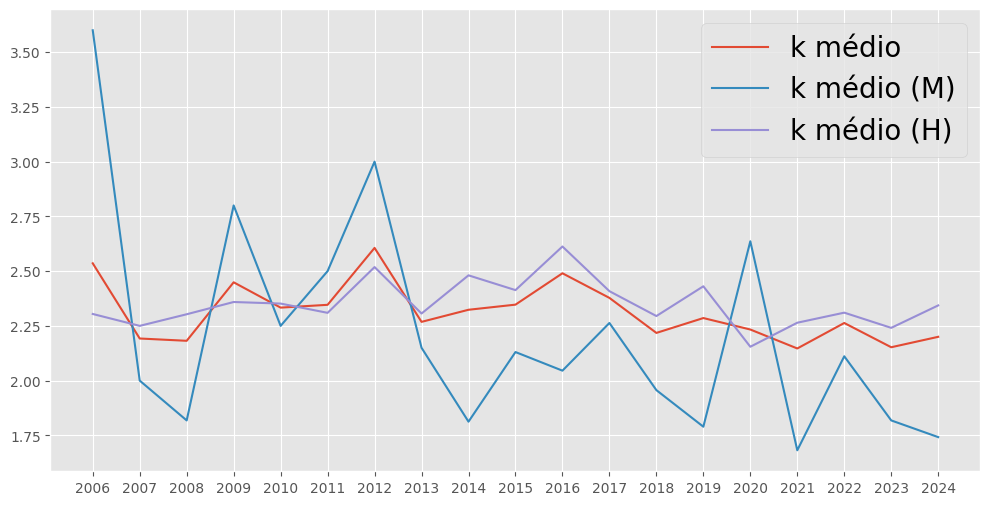

In [152]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(range(2006, 2025), df_dict["k"], label="k médio")
ax.plot(range(2006, 2025), df_dict["k_F"], label="k médio (M)")
ax.plot(range(2006, 2025), df_dict["k_M"], label="k médio (H)")
ax.legend(fontsize=20)
_=ax.set_xticks(range(2006,2025))

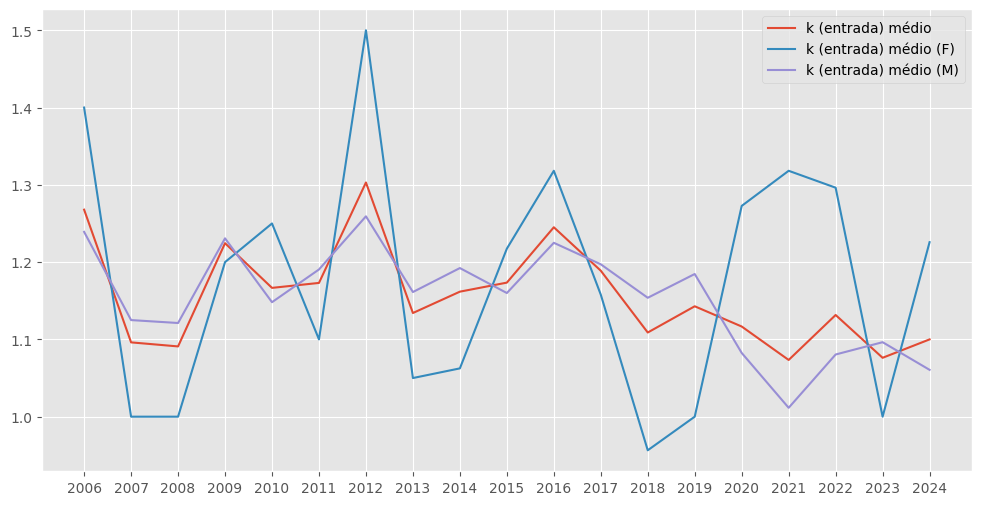

In [143]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(range(2006, 2025), df_dict["k_in"], label="k (entrada) médio")
ax.plot(range(2006, 2025), df_dict["k_in_F"], label="k (entrada) médio (F)")
ax.plot(range(2006, 2025), df_dict["k_in_M"], label="k (entrada) médio (M)")
ax.legend()
_=ax.set_xticks(range(2006,2025))

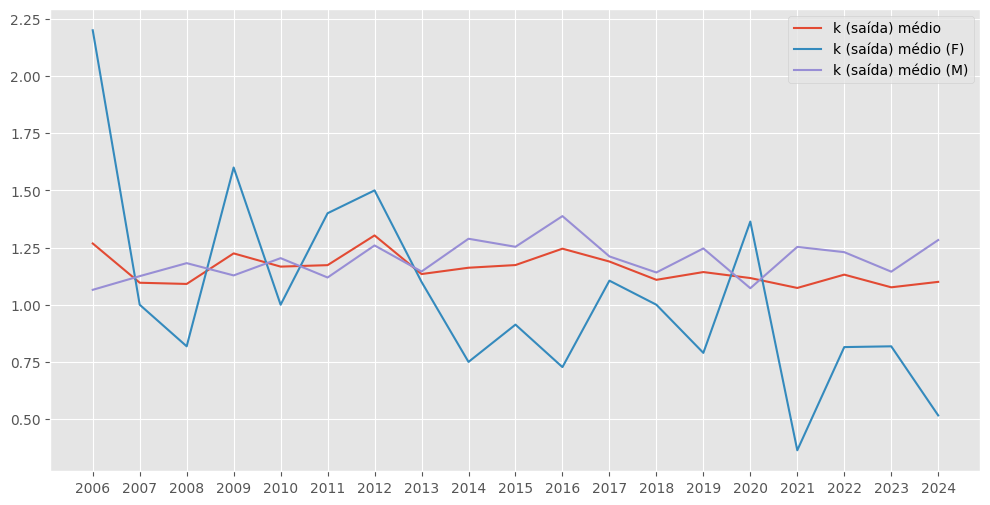

In [144]:
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(range(2006, 2025), df_dict["k_out"], label="k (saída) médio")
ax.plot(range(2006, 2025), df_dict["k_out_F"], label="k (saída) médio (F)")
ax.plot(range(2006, 2025), df_dict["k_out_M"], label="k (saída) médio (M)")
ax.legend()
_=ax.set_xticks(range(2006,2025))

## IES que colaboraram +

In [155]:
node1

{'nome': 'BULGARELI, J V',
 'filiacao': 'Universidade Federal de Uberlândia',
 'genero': 'Feminino',
 'filiacao_genero': 'Feminino_externo',
 'bipartite': 1,
 'marker': 'F',
 'cor_bin': 'blue',
 'cor': 'linen'}

In [156]:
filiacao_alvo = "Universidade Estadual de Campinas"
dict_ano = nx.get_edge_attributes(grafo_defesas, name="ano")
df_dict = collections.defaultdict(list)
for person1, person2, infos in grafo_defesas.edges(data=True):
    node1 = grafo_defesas.nodes[person1]
    node2 = grafo_defesas.nodes[person2]
    df_dict["orient_filiacao_bin"].append("Unicamp" if node1['filiacao'] == filiacao_alvo else "Externa/o")
    df_dict["aval_filiacao_bin"].append("Unicamp" if node2['filiacao'] == filiacao_alvo else "Externa/o")
    df_dict["orient_genero"].append(node1["genero"])
    df_dict["aval_genero"].append(node2["genero"])
    df_dict["aval_filiacao"].append(node2["filiacao"])
    df_dict["ano_defesa"].append(infos["ano"])
    df_dict["tipo_defesa"].append(infos["tipo"])
    df_dict["pessoa orientadora"].append(node1["nome"])
    df_dict["pessoa avaliadora"].append(node2["nome"])
    # break
df = pd.DataFrame(df_dict)

<Axes: xlabel='count', ylabel='aval_filiacao'>

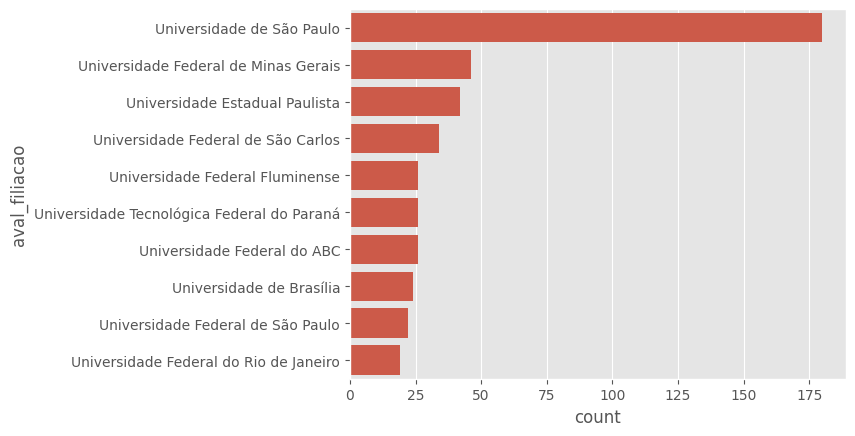

In [154]:
sns.countplot(data=df, y="aval_filiacao", order=df.aval_filiacao.value_counts().iloc[1:11].index)

<Axes: xlabel='count', ylabel='pessoa orientadora'>

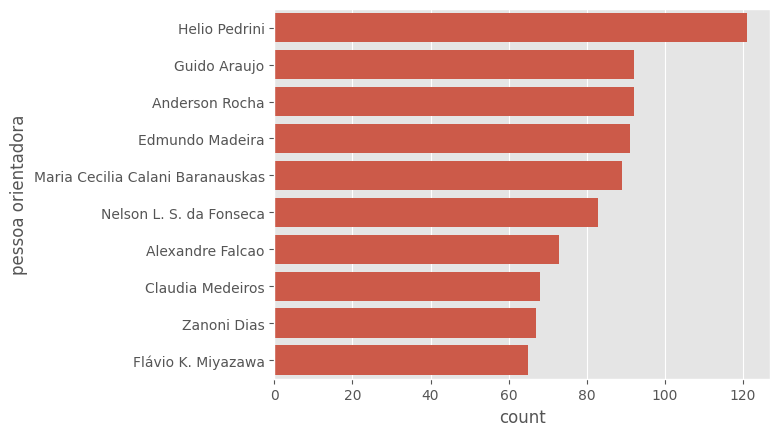

In [159]:
sns.countplot(data=df, y="pessoa orientadora", order=df["pessoa orientadora"].value_counts().iloc[1:11].index)

<Axes: xlabel='count', ylabel='pessoa avaliadora'>

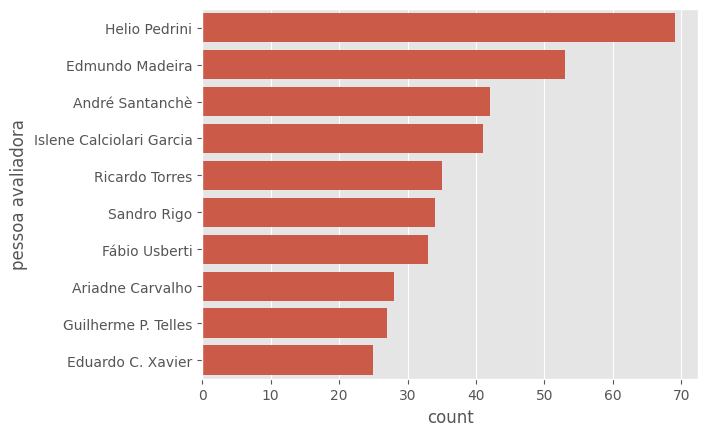

In [158]:
sns.countplot(data=df, y="pessoa avaliadora", order=df["pessoa avaliadora"].value_counts().iloc[0:10].index)